# Waveform I/O module for RIT catalogue.
## Authors: Vaishak Prasad

[comment]: <> (Abstract: TODO)

**Notebook Status:** <font color='green'><b> Production </b></font> 

**Notes:** 
Initiated on 5 Mar 2023

## Introduction:
This notebook describes the sub-routines for 

1. Loading RIT waveform data (Strain $rh/M$ and $\Psi_4$) into modes_array.
2. Loading into waveforms modes_array

In [1]:
import numpy as np
import waveformtools
import matplotlib.pyplot as plt

#####################
# matplotlib presets
#########################################

labelsize=16
labelpad=14

plt.rcParams.update({'font.size': 12})
plt.rcParams.update({"figure.figsize" : (8,6)})
plt.rcParams.update({"axes.grid" : True})
plt.rcParams.update({"axes.labelpad" : labelpad})
plt.rcParams.update({"axes.labelsize" : labelsize})
plt.rcParams.update({"figure.autolayout" : True})
plt.rcParams.update({"grid.alpha" : 0.3})
plt.rcParams.update({"grid.alpha" : 0.3})
plt.rcParams.update({'legend.markerscale': 12})


Bad key text.latex.preview in file /home/vaishakp/Softwares/anaconda3/envs/py3/lib/python3.8/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 123 ('text.latex.preview : False')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.6.2/matplotlibrc.template
or from the matplotlib source distribution

Bad key mathtext.fallback_to_cm in file /home/vaishakp/Softwares/anaconda3/envs/py3/lib/python3.8/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 155 ('mathtext.fallback_to_cm : True  # When True, use symbols from the Computer Modern')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.6.2/matplotlibrc.template
or from the matplotlib source distribution

Bad key savefig.jpeg_quality in file /home/vaishakp/Softwares/anaconda3/envs/py3/lib/python3.8/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 418 ('savefig.jp

# Load RIT Psi4 type data

In [2]:
def get_ell_max_RIT(fdir, var_type='Psi4', fname='*.h5'):
    ''' Get the largest available mode number from available data.
    
    Parameters
    ----------
    fdir :  string
                A string containing the directory path where the mode files can be found.
    var_type: string, optional
            A string that denotes the variable that is being loaded. Options are Psi4 and strain.
            The former is the default.
    fname : string, optional
              The h5 file that contains the modes data. It defaults to the only file in the directory.
              If there are multiple files, it throws an error.
    Returns
    -------
    ell_max : int
              The maximum available ell.
    keys_list : list
                A list of data access keys.
              
    '''
    import re
    
    if var_type=='Psi4':
        import os

        # Get files
        all_fnames = os.listdir(fdir)
        # Get only files
        all_fnames = [item for item in all_fnames if os.path.isfile(f'{fdir}/{item}')]
       
    elif var_type=='Strain':
        import h5py
        
        data_file = h5py.File(f'{fdir}/{fname}.h5')
        all_fnames = list(data_file.keys())
        data_file.close()
        #print(all_fnames)
   
        
    # Parse ell values
    # Filter the keys.
    all_fnames = [item for item in all_fnames if '_l' in item]  
    #print(all_fnames)
    
    # available mode numbers
    all_ell_modes = set({})
    
    # Get mode numbers
    for item in all_fnames:
        
        this_match = re.search('\_l\d\_', item)
        
        if this_match==None:
            #print(f'Skipped file {item}')
            continue
            
        #print('Match found', this_match.string)
        s1, s2 = this_match.span()
        this_ell = int(this_match.string[s1+2:s2-1])
        #print(this_ell)
        
        all_ell_modes.add(this_ell)
        
    ell_max = max(all_ell_modes) 
    return ell_max, all_fnames
    
    

In [2]:
fdir = "/home/vaishakp/Downloads/ExtrapPsi4_RIT-BBH-0001-n100-id3"

#get_ell_max_RIT(fdir)

In [4]:
def load_RIT_Psi4_from_disk(fdir, alias='RIT_rPsi4inf', ell_max=None, save_as_ma=False, spin_weight=-2, resam_type='finest', interp_kind='cubic'):
    ''' Load the Psi4 waveforms from the RIT catalogue
        from ASCII files from disk.
        
        Parameters
        ----------
        fdir :  string
                A string containing the directory path where the mode files can be found.
        alias : string, optional
                The alias of the modes_array object.
        ell_max : int, optional
                    The maximum mode number to load. If not specified, 
                    then all available modes are loaded.
        save_as_ma : bool, optional
                     Save to disk again as a modes_array h5 file?
        spin_weight : int, optional
                      The spin weight of the object. Used for filtering modes.
                      Defaults to -2. 
        resam_type : string, float, optional
                     The type of resampling to do. Options are finest and coarsest, and user input float.
        interp_kind : string, optional
                      The interpolation type to use. Default is cubic.
                      
        Returns
        -------
        
        rit_modes_array : modes_array
                            A modes_array instance containing the loaded modes.
                            
        Notes
        -----
        It seems like the time axis of individual modes are identical to each other. Hence, one need not worry about 
        choosing the time domain. This may change in future.
        '''
    
    
    
    from waveformtools import waveforms
    from waveformtools.waveforms import modes_array
    
    # Max available mode l.
    if ell_max == None:
        ell_max, _ = get_ell_max_RIT(fdir)

    # Construct a modes list
    wf_modes_list = waveforms.construct_mode_list(ell_max = ell_max, spin_weight=spin_weight)

    print('The modes list is', wf_modes_list)


    
    # For interpolation
    from scipy.interpolate import interp1d

    # Alias of the modes_array
    #alias = 'q1a0_a'

    # Create a modes array
    wfa = modes_array(label=alias, data_dir=fdir, modes_list=wf_modes_list)

    # Enforce only l>2 modes.
    wf_modes_list = [item for item in wf_modes_list if item[0]>=abs(spin_weight)]

    tend = []
    tstart = []

    ##########################################
    # Read in the data
    #########################################
    
    print('Reading in modes...')
    for ell, emm_list in wf_modes_list:
        for emm in emm_list:

            print('Loading', ell, emm)
            # Construct file path
            wf_psi4_file_path = fdir + f'/rPsi4_l{ell}_m{emm}_rInf.asc'
            # Read in the data
            wf_psi4_file = np.genfromtxt(wf_psi4_file_path)

            # Get time axis
            wf_psi4_time = wf_psi4_file[:, 0]
            #tend.append(len(wf_psi4_time))
            #tstart.append(wf_psi4_time[0])
            #tend.append(wf_psi4_time[-1])
            
            #print(f'Tmin {wf_psi4_time[0]}, tmax{wf_psi4_time[-1]}')
            # Create modes_array on first run
            
            #print(wfa.modes_data)
            if wfa.modes_data.all()==np.array(None):
                print('Creating modes data')

                min_dt = round(min(np.diff(wf_psi4_time)), 2)
                max_dt = round(max(np.diff(wf_psi4_time)), 2)
                print(f'Min dt {min_dt} and Max dt {max_dt}')
                
                if resam_type=='finest':
                    # Choose finest available timestep
                    # for upto 3 decimal digits.
                    m_dt = min_dt
                    print('Resampling at the finest timestep', m_dt)
                if resam_type=='coarsest':
                    m_dt = max_dt
                    print('Resampling at the coarsest timestep', m_dt)
                
                if isinstance(resam_type, float):
                    m_dt = resam_type
                    print('Resampling at user defined timestep', m_dt)
                    
                    
                # New (resampled) time axis
                time_axis = np.arange(wf_psi4_time[0], wf_psi4_time[-1]+m_dt, m_dt)

                # Length of data.
                data_len = len(time_axis)

                # Create a modes array object
                wfa._create_modes_array(ell_max=ell_max, data_len=data_len)

                # Assign to it the time axis
                wfa.time_axis = time_axis

            #print(wfa.time_axis - wf_psi4_time)
            #continue
            ###################################
            # Uniform sampling
            ###################################
            #print('Wfa time axis', wfa.time_axis)

            ###############################
            # Load the phase data
            ##############################

            Yphase = wf_psi4_file[:, 4]
            Yphase_interp_fun = interp1d(wf_psi4_time, Yphase, kind=interp_kind)

            # Resample
        
            Yphase_resam = Yphase_interp_fun(time_axis)
     
            ###########################
            # Load the amplitude data
            ###########################
            Yamp = wf_psi4_file[:, 3]
            Yamp_interp_fun = interp1d(wf_psi4_time, Yamp, kind=interp_kind)

            # Resample
            Yamp_resam = Yamp_interp_fun(time_axis)
            wfmode = Yamp_resam * np.exp(1j*Yphase_resam)

            ###################################
            # Load the modes data
            ###################################

            wfa.set_mode_data(ell, emm, wfmode)


    # Trim or recenter     
    wfa.trim(trim_upto_time=0)


    if save_as_ma==True:
        # Save the modes array as waveforms hdf file
        wfa.save_modes(out_file_name='{alias}_resam.h5')   
            
                
                
    return wfa

In [5]:
from waveformtools import dataIO 

In [6]:
wp = dataIO.load_RIT_Psi4_from_disk(fdir=fdir)

The modes list is [[0, [0]], [1, [-1, 0, 1]], [2, [-2, -1, 0, 1, 2]], [3, [-3, -2, -1, 0, 1, 2, 3]], [4, [-4, -3, -2, -1, 0, 1, 2, 3, 4]]]
Reading in modes...
Loading 2 -2


NameError: name 'np' is not defined

In [6]:
wp.modes_list

[[0, [0]],
 [1, [-1, 0, 1]],
 [2, [-2, -1, 0, 1, 2]],
 [3, [-3, -2, -1, 0, 1, 2, 3]],
 [4, [-4, -3, -2, -1, 0, 1, 2, 3, 4]]]

In [7]:
wp.mode(2, 2)

array([-4.87777261e-05+1.92715570e-04j,  1.25849533e-06+4.67168698e-06j,
        1.27819124e-06+4.63826788e-06j, ...,
        2.68202063e-07-2.96248143e-07j,  2.57651712e-07-2.99419796e-07j,
       -3.17648482e-06-1.76997716e-06j])

In [8]:
wp.time_axis

array([-860.5 , -860.25, -860.  , ...,  338.  ,  338.25,  338.5 ])

/home/vaishakp/Softwares/anaconda3/envs/py3/lib/python3.8/site-packages/matplotlib/collections.py:193: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


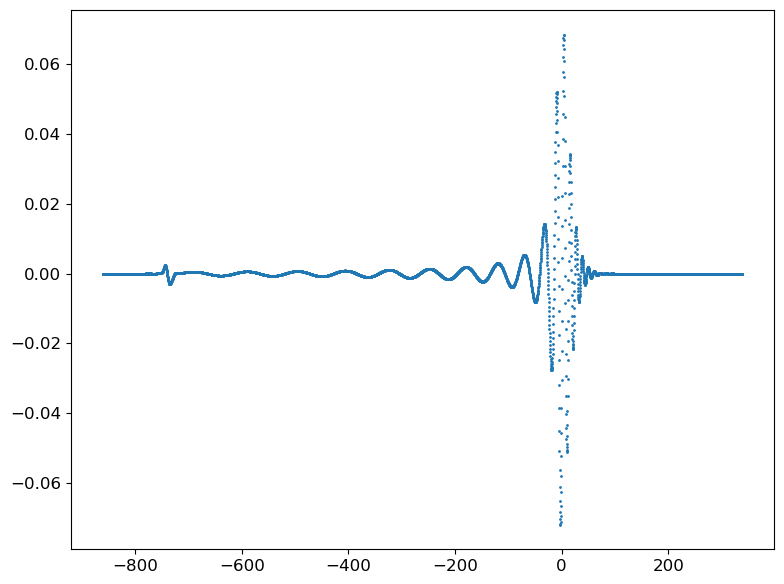

In [9]:
plt.scatter(wp.time_axis, wp.mode(2, 2), s=1)
plt.grid()
plt.show()


# Load RIT strain type data.

In [10]:
fdir = "/home/vaishakp/Downloads"
fname = "ExtrapStrain_RIT-BBH-0001-n100"
var_type='Strain'
get_ell_max_RIT(fdir, fname=fname, var_type=var_type)

(4,
 ['amp_l2_m-1',
  'amp_l2_m-2',
  'amp_l2_m0',
  'amp_l2_m1',
  'amp_l2_m2',
  'amp_l3_m-1',
  'amp_l3_m-2',
  'amp_l3_m-3',
  'amp_l3_m0',
  'amp_l3_m1',
  'amp_l3_m2',
  'amp_l3_m3',
  'amp_l4_m-1',
  'amp_l4_m-2',
  'amp_l4_m-3',
  'amp_l4_m-4',
  'amp_l4_m0',
  'amp_l4_m1',
  'amp_l4_m2',
  'amp_l4_m3',
  'amp_l4_m4',
  'phase_l2_m-1',
  'phase_l2_m-2',
  'phase_l2_m0',
  'phase_l2_m1',
  'phase_l2_m2',
  'phase_l3_m-1',
  'phase_l3_m-2',
  'phase_l3_m-3',
  'phase_l3_m0',
  'phase_l3_m1',
  'phase_l3_m2',
  'phase_l3_m3',
  'phase_l4_m-1',
  'phase_l4_m-2',
  'phase_l4_m-3',
  'phase_l4_m-4',
  'phase_l4_m0',
  'phase_l4_m1',
  'phase_l4_m2',
  'phase_l4_m3',
  'phase_l4_m4'])

In [11]:
def load_RIT_strain_from_disk(fdir, fname='*', alias='RIT_strain', ell_max=None, save_as_ma=False, spin_weight=-2, resam_type='finest', interp_kind='cubic'):
    ''' Load the RIT strain waveforms from the RIT catalogue,
        from hdf5 files from disk.
        
        Parameters
        ----------
        fdir :  string
                A string containing the directory path where the mode files can be found.
        alias : string, optional
                The alias of the modes_array object.
        ell_max : int, optional
                    The maximum mode number to load. If not specified, 
                    then all available modes are loaded.
        save_as_ma : bool, optional
                     Save to disk again as a modes_array h5 file?
        spin_weight : int, optional
                      The spin weight of the object. Used for filtering modes.
                      Defaults to -2. 
        resam_type : string, float, optional
                     The type of resampling to do. Options are finest and coarsest, and user input float.
        interp_kind : string, optional
                      The interpolation type to use. Default is cubic.
                      
        Returns
        -------
        
        rit_modes_array : modes_array
                            A modes_array instance containing the loaded modes.
                            
        Notes
        -----
        It seems like the time axis of individual modes are identical to each other. Hence, one need not worry about 
        choosing the time domain. This may change in future.
        '''
    
    
    
    from waveformtools import waveforms
    from waveformtools.waveforms import modes_array
    
    # Max available mode l.
    ell_max_act, keys_list = get_ell_max_RIT(fdir=fdir, var_type='Strain', fname=fname)
    if ell_max == None:
        ell_max = ell_max_act
    
    #one_key = keys_list[0]
    
    # Construct a modes list
    wf_modes_list = waveforms.construct_mode_list(ell_max = ell_max, spin_weight=spin_weight)

    print('The modes list is', wf_modes_list)


    
    # For interpolation
    from scipy.interpolate import interp1d

    # Alias of the modes_array
    #alias = 'q1a0_a'

    # Create a modes array
    wfa = modes_array(label=alias, data_dir=fdir, modes_list=wf_modes_list)

    # Enforce only l>2 modes.
    wf_modes_list = [item for item in wf_modes_list if item[0]>=abs(spin_weight)]

    tend = []
    tstart = []

    ##########################################
    # Read in the data
    #########################################
    
    # Get the time axis
    import h5py
    data_file = h5py.File(f'{fdir}/{fname}.h5')
    
    time_axis = data_file['NRTimes'][...]
    dt_auto = time_axis[1]-time_axis[0]
    
    print('Reading in modes...')
    for ell, emm_list in wf_modes_list:
        for emm in emm_list:
            
            this_amp_key = f'amp_l{ell}_m{emm}'
            this_phase_key = f'phase_l{ell}_m{emm}'

            print('Loading', ell, emm)
            # Construct file path
        
            # Create modes_array on first run
            
            #print(wfa.modes_data)
            if wfa.modes_data.all()==np.array(None):
                print('Creating modes data')

                #min_dt = round(min(np.diff(wf_psi4_time)), 2)
                #max_dt = round(max(np.diff(wf_psi4_time)), 2)
                print(f'Default dt is {dt_auto}')
                
                if resam_type=='auto':
                    # Choose finest available timestep
                    # for upto 3 decimal digits.
                    m_dt = dt_auto
                    print('Sampling at the default timestep', m_dt)
                
                if isinstance(resam_type, float):
                    m_dt = resam_type
                    print('Resampling at user defined timestep', m_dt)
                    
                    
                    # New (resampled) time axis
                    time_axis = np.arange(time_axis[0], time_axis[-1]+dt_auto, m_dt)

                # Length of data.
                data_len = len(time_axis)

                # Create a modes array object
                wfa._create_modes_array(ell_max=ell_max, data_len=data_len)

                # Assign to it the time axis
                wfa.time_axis = time_axis

            #print(wfa.time_axis - wf_psi4_time)
            #continue
            ###################################
            # Uniform sampling
            ###################################
            #print('Wfa time axis', wfa.time_axis)

            ###############################
            # Load the phase data
            ##############################
            Tphase = data_file[this_phase_key]['X'][...]
            
            Yphase = data_file[this_phase_key]['Y'][...]
            
            
            Yphase_interp_fun = interp1d(Tphase, Yphase, kind=interp_kind)

            # Resample
        
            Yphase_resam = Yphase_interp_fun(time_axis)
     
            ###########################
            # Load the amplitude data
            ###########################
            Tamp = data_file[this_amp_key]['X'][...]
            
            Yamp = data_file[this_amp_key]['Y'][...]
            
            
            Yamp_interp_fun = interp1d(Tamp, Yamp, kind=interp_kind)

            # Resample
        
            Yamp_resam = Yamp_interp_fun(time_axis)

            wfmode = Yamp_resam * np.exp(1j*Yphase_resam)

            ###################################
            # Load the modes data
            ###################################

            wfa.set_mode_data(ell, emm, wfmode)

    data_file.close()
    # Trim or recenter     
    wfa.trim(trim_upto_time=0)

    #print(wfa.get_metadata())
    if save_as_ma==True:
        # Save the modes array as waveforms hdf file
        wfa.save_modes(out_file_name=f'{alias}_resam.h5')   
            
                
                
    return wfa

In [12]:
ws = load_RIT_strain_from_disk(fdir=fdir, fname=fname, save_as_ma=True)

The modes list is [[0, [0]], [1, [-1, 0, 1]], [2, [-2, -1, 0, 1, 2]], [3, [-3, -2, -1, 0, 1, 2, 3]], [4, [-4, -3, -2, -1, 0, 1, 2, 3, 4]]]
Reading in modes...
Loading 2 -2
Creating modes data
Default dt is 0.25
Loading 2 -1
Loading 2 0
Loading 2 1
Loading 2 2
Loading 3 -3
Loading 3 -2
Loading 3 -1
Loading 3 0
Loading 3 1
Loading 3 2
Loading 3 3
Loading 4 -4
Loading 4 -3
Loading 4 -2
Loading 4 -1
Loading 4 0
Loading 4 1
Loading 4 2
Loading 4 3
Loading 4 4
{'label': 'RIT_strain', 'data_dir': '/home/vaishakp/Downloads', 'file_name': None, 'key_format': None, 'ell_max': None, 'modes_list': [[0, [0]], [1, [-1, 0, 1]], [2, [-2, -1, 0, 1, 2]], [3, [-3, -2, -1, 0, 1, 2, 3]], [4, [-4, -3, -2, -1, 0, 1, 2, 3, 4]]], 'r_ext': 500, 'frequency_axis': None, 'out_file_name': None, 'maxtime': None, 'date': '2023-03-06', 'time': '20:29:43', 'key_ex': None, 'spin_weight': None}


In [13]:
ws.label

'RIT_strain'

In [14]:
ws.data_dir

'/home/vaishakp/Downloads'

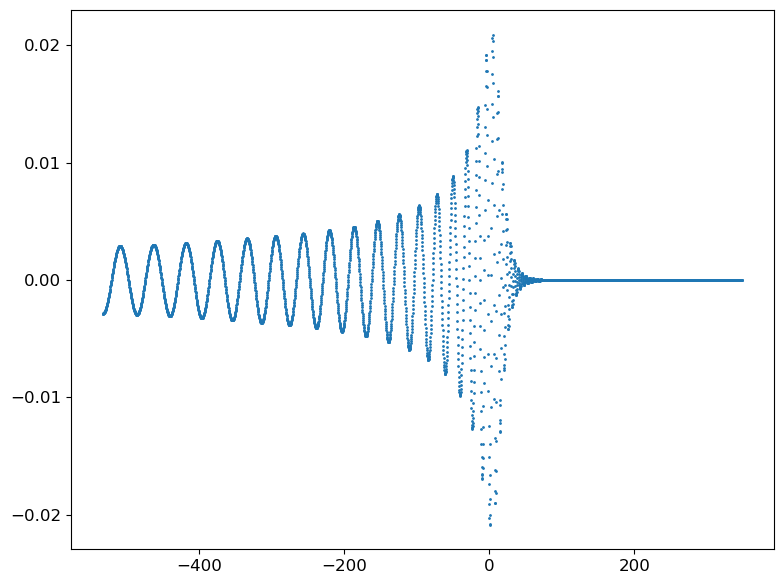

In [15]:
plt.scatter(ws.time_axis, ws.mode(4, 4), s=1)
plt.grid()
plt.show()


In [16]:
ws.time_axis

array([-532.75, -532.5 , -532.25, ...,  347.75,  348.  ,  348.25],
      dtype=float32)

In [17]:
ws.mode(3, 1)

array([ 5.27940802e-18-2.25503412e-17j,  5.30994631e-18-2.29257011e-17j,
        5.33095592e-18-2.33007984e-17j, ...,
       -2.35928748e-18-2.67332700e-33j, -1.18296789e-18-1.34043012e-33j,
        0.00000000e+00+0.00000000e+00j])

In [18]:
def load_modes():
    (self, r_ext=None, ell_max=None, pre_key=None, modes_list=None, crop=False, centre=True, key_ex=None, r_ext_factor=1):
        """Load the waveform mode data from an hdf file.

        Parameters
        ----------

        pre_key:    str, optional
                                A string containing the key of the group in
                                the HDF file in which the modes` dataset exists.
                                It defaults to `None`.
        mode_numbers:   list
                                        The mode numbers to load from the file.
                                        Each item in the list is a list that
                                        contains two integrer numbers, one for
                                        the mode index :math:`\\ell` and the
                                        other for the mode index :math:`m`.
        crop:   bool
                        Whether or not to crop the beginning of the input
                        waveform. If yes, the first :math:`t=r_{ext}`
                        length of data will be discarded.

        Returns
        -------
        waveform_obj:   3d array
                                        Sets the three dimensional array `waveform.modes` that contains
                                        the required :math:`\\ell, m` modes.

        Examples
        --------
        >>> from waveformtools.waveforms import waveform
        >>> waveform.set_basedir('./')
        >>> waveform.set_datadir('data/')
        >>> mode_numbers = [[2, 2], [3, 3]]
        >>> waveform.load_data(mode_numbers=mode_numbers)
        """

SyntaxError: invalid syntax (<ipython-input-18-5dbbd1a6aae1>, line 2)

In [62]:
def load_wftools_data_from_disk(wfa=None, r_ext=None, ell_max=None, pre_key=None, modes_list=None, crop=False, centre=True, key_ex=None, r_ext_factor=1): 
    ''' Load the RIT strain waveforms from the RIT catalogue,
        from hdf5 files from disk.
        
        Parameters
        ----------
        fdir :  string
                A string containing the directory path where the mode files can be found.
        alias : string, optional
                The alias of the modes_array object.
        ell_max : int, optional
                    The maximum mode number to load. If not specified, 
                    then all available modes are loaded.
        save_as_ma : bool, optional
                     Save to disk again as a modes_array h5 file?
        spin_weight : int, optional
                      The spin weight of the object. Used for filtering modes.
                      Defaults to -2. 
        resam_type : string, float, optional
                     The type of resampling to do. Options are finest and coarsest, and user input float.
        interp_kind : string, optional
                      The interpolation type to use. Default is cubic.
                      
        Returns
        -------
        
        rit_modes_array : modes_array
                            A modes_array instance containing the loaded modes.
                            
        Notes
        -----
        It seems like the time axis of individual modes are identical to each other. Hence, one need not worry about 
        choosing the time domain. This may change in future.
    
    '''
    import sys, re
    from waveformtools.waveforms import _get_modes_list_from_keys
    from waveformtools.waveformtools import message
    if not wfa:
        # Create a modes array
        wfa = modes_array(label=alias, data_dir=fdir, modes_list=wf_modes_list)

    # Enforce only l>2 modes.
    #wf_modes_list = [item for item in wf_modes_list if item[0]>=abs(spin_weight)]
    
    
    # Open the modes file.
    import h5py, json
    full_path = wfa.data_dir + "/" + wfa.file_name
    
    #print(wfa.file_name)
    with h5py.File(full_path, "r") as wfile:

        #################################
        # Get metadata
        ###############################

        # Load metadata if present.
        try:
       # if 1:
            metadata_bytes = bytes(np.void(wfile["metadata"])).decode()
            metadata = json.loads(metadata_bytes)
            #print(metadata)
            # Import the metadata.
            for key, val in metadata.items():
                if val is not None:
                    wfa.__dict__.update({key : val})
            message("Metadata loaded")
            print('Waveform meta data:', wfa.get_metadata())
            
        except:
            # If no metadata found, pass empty dict for updation.
            print('No metadata found!')
            metadata = {}
            pass
        #print(wfa.file_name)
        # data = np.array(wfile['l0_m0_r500.00'])
        # print(data)
        # Get the list of keys.
        modes_keys_list = list(wfile.keys())
        #print('Keys ', modes_keys_list)
        #print(wfa.get_metadata())
        # Check and filter for particular key string pattern

        if key_ex is not None:
            # Filter the keys according to key_ex if specified.
            print('Filtering as per', key_ex)
            wfa.key_ex=key_ex
            modes_keys_list=[item for item in modes_keys_list if key_ex in item]
            #print(modes_keys_list)

        else:
            print('key_ex is not specified. Proceeding without filtering..')
            
        modes_keys_list = sorted(modes_keys_list)

        #print('Modes keys', modes_keys_list)
        wfa.mode_keys_list = modes_keys_list
        
        
        # Construct the list of modes if it doesnt exist.
    
        ##########################
        # Construct modes list
        ##########################
        if r_ext:
            wfa.r_ext = r_ext
        elif wfa.r_ext is not None:
            r_ext = wfa.r_ext
        else:
            message('Unable to parse extraction radius!')
            sys.exit(0)
        if not modes_list:
            # Check if modes list is given for which mode to load.
            # If the list of modes is not given then construct the list of modes.

            if not ell_max:
                # If ell max is also not specified,
                # construct the list of modes using
                # the list of modes h5 file keys.
                modes_list = _get_modes_list_from_keys(modes_keys_list, r_ext)
                #print(modes_list)
                # Get the ell max
                ell_max = max([item[0] for item in modes_list])
                
                #metadata.update({ell_max : ell_max })
                wfa.ell_max = ell_max 

            else:
                # self.ell_max = ell_max
                # If ell max is given, construct the
                # list of modes directly.
                modes_list = construct_mode_list(ell_max)

                # set the modes list attr.
                self.modes_list = modes_list

        else:
            #self.modes_list = modes_list
            # If modes list is given, get ell_max from it.
            if not ell_max:
                # Get the ell max
                ell_max = max([item[0] for item in modes_list])


        # Set the ell_max attribute if not already.
        if not wfa.ell_max:
            wfa.ell_max = ell_max

        #################################################
        # Load modes
        #################################################
        # Modes array created flag
        cflag=0
        # Load the modes listed in mode_numbers list
        for item in modes_list:
            # For every ell mode list in modes_list

            ell_value, emm_list = item

            for emm_index, emm_value in enumerate(emm_list):
                # For every (ell, emm) mode.

                # Find the key corresponding to the mode
                try:
                    key = str(
                        [
                            item
                            for item in modes_keys_list
                            if re.search(f"l{ell_value}_m{emm_value}_r{r_ext}", item)
                        ][0]
                    )
                    # print('The loaded key is ', key, type(key))
                    # print('The loaded key is ', key, type(key))
                    # if key=='l0_m0_r500.00':
                    # print('Its alright')
                except:
                    message(f"Waveform dataset for l{ell_value}, m{emm_value} not found")
                    sys.exit(0)


            # Get the data
                data = np.array(wfile[key])

                # set the time and data axis
                time_axis = data[:, 0]
                data_re = data[:, 1]
                data_im = data[:, 2]
                
                # create flag
                if not cflag:
                    if wfa.modes_data.all()==np.array(None):

                        if crop:
                            # Crop the beginning portion.
                            delta_t = time_axis[1] - time_axis[0]
                            shift = int(self.r_ext / delta_t)

                        else:
                            shift = 0
                        data_len = len(time_axis) - shift
                        wfa.data_len = data_len
                        # Delete the attribute
                        #del self.modes_data
                        # Create an array for the waveform mode object
                        wfa._create_modes_array(wfa.ell_max, data_len)
                        # self.modes_data = np.zeros([ell_max+1, 2*(ell_max+1) +1, data_len], dtype=np.complex128)
                        #self.modes_data = np.zeros([ell_max+1, 2*(ell_max+1) +1, data_len], dtype=np.complex128)

                        cflag = 1

                        # set the time axis.
                        wfa.time_axis = time_axis[shift:]

                wfa.set_mode_data(ell_value, emm_value, r_ext_factor*(data_re[shift:] + 1j * data_im[shift:]))

        ##############################
        # Recenter axis
        ##############################
        # Trim or recenter     
        if centre:
            wfa.trim(trim_upto_time=0)
        
        #maxloc = np.argmax(np.absolute(self.mode(2, 2)))
        #maxtime = time_axis[shift + maxloc]
        
        #if wfa.maxtime is None:
        #    wfa.maxtime = maxtime
        #print("Max time is", maxtime)

        #if centre:
        #    wfa.time_axis = time_axis[shift:] - maxtime
        #print(wfa.file_name)
        return wfa

In [63]:
ws.data_dir

'/home/vaishakp/Downloads'

In [64]:
ws.file_name

In [65]:
ww1 = waveformtools.waveforms.modes_array()
ww1.data_dir='/home/vaishakp/Downloads'
ww1.file_name='RIT_strain_RIT_strain_resam.h5'

In [66]:
ww2 = load_wftools_data_from_disk(wfa=ww1)

Metadata loaded
Waveform meta data: {'label': 'RIT_strain', 'data_dir': '/home/vaishakp/Downloads', 'file_name': 'RIT_strain_RIT_strain_resam.h5', 'key_format': None, 'ell_max': None, 'modes_list': [[0, [0]], [1, [-1, 0, 1]], [2, [-2, -1, 0, 1, 2]], [3, [-3, -2, -1, 0, 1, 2, 3]], [4, [-4, -3, -2, -1, 0, 1, 2, 3, 4]]], 'r_ext': 500, 'frequency_axis': None, 'out_file_name': 'RIT_strain_RIT_strain_resam.h5', 'maxtime': None, 'date': '2023-03-06', 'time': '20:29:43', 'key_ex': None, 'spin_weight': None}
key_ex is not specified. Proceeding without filtering..


In [27]:
ww1.data_dir

'/home/vaishakp/Downloads'

In [30]:
ww1.file_name

'RIT_strain_RIT_strain_resam.h5'

In [52]:
ww2.get_metadata()

{'label': 'RIT_strain',
 'data_dir': '/home/vaishakp/Downloads',
 'file_name': 'RIT_strain_RIT_strain_resam.h5',
 'key_format': None,
 'ell_max': 4,
 'modes_list': [[0, [0]],
  [1, [-1, 0, 1]],
  [2, [-2, -1, 0, 1, 2]],
  [3, [-3, -2, -1, 0, 1, 2, 3]],
  [4, [-4, -3, -2, -1, 0, 1, 2, 3, 4]]],
 'r_ext': 500,
 'frequency_axis': None,
 'out_file_name': 'RIT_strain_RIT_strain_resam.h5',
 'maxtime': None,
 'date': '2023-03-06',
 'time': '20:29:43',
 'key_ex': None,
 'spin_weight': None,
 'mode_keys_list': ['l0_m0_r500.00',
  'l1_m-1_r500.00',
  'l1_m0_r500.00',
  'l1_m1_r500.00',
  'l2_m-1_r500.00',
  'l2_m-2_r500.00',
  'l2_m0_r500.00',
  'l2_m1_r500.00',
  'l2_m2_r500.00',
  'l3_m-1_r500.00',
  'l3_m-2_r500.00',
  'l3_m-3_r500.00',
  'l3_m0_r500.00',
  'l3_m1_r500.00',
  'l3_m2_r500.00',
  'l3_m3_r500.00',
  'l4_m-1_r500.00',
  'l4_m-2_r500.00',
  'l4_m-3_r500.00',
  'l4_m-4_r500.00',
  'l4_m0_r500.00',
  'l4_m1_r500.00',
  'l4_m2_r500.00',
  'l4_m3_r500.00',
  'l4_m4_r500.00',
  'metadat

In [30]:
ww2.file_name

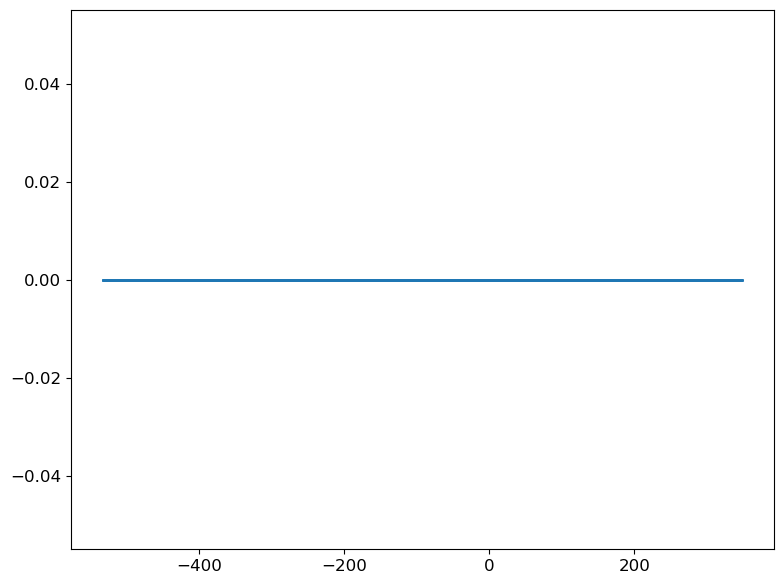

In [56]:
plt.scatter(ww2.time_axis, ww2.mode(3, 2) - ws.mode(3, 2), s=1)
plt.grid()
plt.show()


# Read in GWF data

In [5]:
from gwpy.timeseries import TimeSeries

In [6]:
TimeSeries.channel('/home/vaishakp/Downloads/L-L1_GWOSC_O3b_4KHZ_R1-1256652800-4096.gwf')

TypeError: 'property' object is not callable

In [20]:
data = TimeSeries.read('/home/vaishakp/Downloads/L-L1_GWOSC_O3b_4KHZ_R1-1256652800-4096.gwf', 'L1:DCS-CALIB_STRAIN_CLEAN_SUB60HZ_C01')

RuntimeError: channel 'L1:DCS-CALIB_STRAIN_CLEAN_SUB60HZ_C01' not found

In [81]:
def load_SpECTRE_data_from_disk(wfa=None, 
                            alias='SXS Strain',
                            fdir="./",
                            fname="rhOverM_Extrapolated_N5_CoM_Mem.h5",
                            r_ext=None, 
                            ell_max=12,   
                            centre=True,
                            modes_list=None,
                            r_ext_factor=1,
                            save_as_ma='False',
                            resam_type='auto',
                            interp_kind='cubic',
                            compression_opts=0,
                            ): 
    ''' Load the SXS waveforms to modes_array,from hdf5 files from disk.
        
        Parameters
        ----------
        wfa : modes_array, optional
              The modes array to which to store the loaded waveform to. A new modes array will be returned
              if not provided.
        fdir :  string
                A string containing the directory path where the mode files can be found.
        fname : string
                The name of the file containing the waveform data.
        alias : string, optional
                The alias of the modes_array object.
        ell_max : int, optional
                    The maximum mode number to load. If not specified, 
                    then all available modes are loaded.
        save_as_ma : bool, optional
                     Save to disk again as a modes_array h5 file?
        resam_type : string, float, optional
                     The type of resampling to do. Options are finest and coarsest, and user input float.
        interp_kind : string, optional
                      The interpolation type to use. Default is cubic.
                      
        Returns
        -------
        
        modes_array : modes_array
                      A modes_array instance containing the loaded modes.
                            
    
    '''
    # Load SXS waveforms to modes_array.
    import sys
    #Spectra infinty
    try:
        import scri
    except:
        print('scri module is required for reading in SXS waveforms. Please install and try again')
        sys.exit(0)
        
    from waveformtools import waveforms
    from waveformtools.waveforms import modes_array
    from waveformtools.waveforms import _get_modes_list_from_keys
    from waveformtools.waveformtools import message
    
   
        
    if not wfa:
        # Create a modes array
        wfa = modes_array(label=label, ell_max=ell_max, modes_list=modes_list)
       #wfa = modes_array(label=alias, data_dir=fdir, modes_list=modes_list)
    
    if not fdir:
        fdir = wfa.data_dir
    else:
        wfa.data_dir = fdir
        
    if not fname:
        fname = wfa.file_name
    else:
        wfa.file_name = fname
    
    if not ell_max:
        ell_max = wfa.ell_max
    else:
        wfa.ell_max = ell_max
    
    #ell_max        = 12
    if not modes_list:
        if not wfa.modes_list:
            print('Constructing the modes list')
            #sys.exit(0)
            modes_list     = waveformtools.waveforms.construct_mode_list(ell_max=ell_max)
        else:
            modes_list = wfa.modes_list
    else:
        wfa.modes_list = modes_list
    
    
    full_path = f"{fdir}/{fname}"
    
    #wf_strain_file_path      = '/home/vaishakprasad/Downloads/waveform_extraction/SpECTRE/q1a0/strain/rhOverM_Extrapolated_N5_CoM_Mem(1).h5'

    wf_file           = scri.rpxmb.load(full_path)[0].to_inertial_frame()

    from scipy.interpolate import interp1d

    flag = None
    
    for item in modes_list:
        ell, emm_list = item
        for emm in emm_list:
            #print(ell, emm)
            wf_data           = wf_file.data[:, wf_file.index(ell, emm)]
            wf_data_re        = wf_data.real
            wf_data_im        = wf_data.imag

            wf_time           = wf_file.t
            #print(type(wfa.modes_data))
            if wfa.modes_data.all()==np.array(None):
                
                time_axis = wf_time
                print('Creating modes data')

                #min_dt = round(min(np.diff(wf_psi4_time)), 2)
                #max_dt = round(max(np.diff(wf_psi4_time)), 2)
                dt_auto = (time_axis[-1] - time_axis[0])/len(time_axis)
                dt_auto = int(dt_auto*100)/100
                
               # print(f'Default dt is {dt_auto}')
                
                min_dt = round(min(np.diff(time_axis)), 2)
                max_dt = round(max(np.diff(time_axis)), 2)
                
                print(f'Min dt {min_dt} and Max dt {max_dt}')
                
                if resam_type=='finest':
                    # Choose finest available timestep
                    # for upto 3 decimal digits.
                    m_dt = min_dt
                    print('Resampling at the finest timestep', m_dt)
                if resam_type=='coarsest':
                    m_dt = max_dt
                    print('Resampling at the coarsest timestep', m_dt)
                
                if isinstance(resam_type, float):
                    m_dt = resam_type
                    print('Resampling at user defined timestep', m_dt)
                         
                if resam_type=='auto':
                    # Choose finest available timestep
                    # for upto 3 decimal digits.
                    m_dt = dt_auto
                    print('Resampling at the default timestep', m_dt)
                    
                # New (resampled) time axis
                time_axis = np.arange(time_axis[0], time_axis[-1], m_dt)

                # Length of data.
                data_len = len(time_axis)
                #print(data_len)
                
                wfa._create_modes_array(ell_max = ell_max, data_len=data_len)
                #print(wfa.mode(0,0).shape)
                wfa.time_axis      = time_axis

            re_int = interp1d(wf_time, wf_data_re)
            #print(wf_time[0], wf_time[-1], time_axis[0], time_axis[-1])
            re_dat = re_int(time_axis)

            im_int = interp1d(wf_time, wf_data_im)
            im_dat = im_int(time_axis)

            wfa.set_mode_data(ell, emm, data=re_dat + 1j*im_dat)
     
    if centre:
        wfa.trim(trim_upto_time=0)

    if save_as_ma==True:
    # Save the modes array as waveforms hdf file
        wfa.save_modes(out_file_name=f'{alias}_resam.h5', compression_opts=compression_opts)   
        
    return wfa

In [74]:
fdir  = '/home/vaishakp/Downloads/'
fname = 'rMPsi4_Asymptotic_GeometricUnits_CoM.h5'
fname = 'rMPsi4_Extrapolated_N7_CoM.h5'
label = 'SXS q1a0 extrap'

wfsxs = load_sxs_data_from_disk(fdir=fdir, fname=fname, alias=label)

Constructing the modes list
Creating modes data
Min dt 0.01 and Max dt 1.08
Resampling at the default timestep 0.36


In [75]:
wfsxs.get_metadata()

{'label': 'SXS q1a0 extrap',
 'data_dir': '/home/vaishakp/Downloads/',
 'file_name': 'rMPsi4_Extrapolated_N7_CoM.h5',
 'key_format': None,
 'ell_max': 12,
 'modes_list': [[0, [0]],
  [1, [-1, 0, 1]],
  [2, [-2, -1, 0, 1, 2]],
  [3, [-3, -2, -1, 0, 1, 2, 3]],
  [4, [-4, -3, -2, -1, 0, 1, 2, 3, 4]],
  [5, [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]],
  [6, [-6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6]],
  [7, [-7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7]],
  [8, [-8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]],
  [9, [-9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9]],
  [10,
   [-10,
    -9,
    -8,
    -7,
    -6,
    -5,
    -4,
    -3,
    -2,
    -1,
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10]],
  [11,
   [-11,
    -10,
    -9,
    -8,
    -7,
    -6,
    -5,
    -4,
    -3,
    -2,
    -1,
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11]],
  [12,
   [-12,
    -11,
    -10,
    -9,
 

In [15]:
import h5py

In [16]:
ff = h5py.File(f"{fdir}/{fname}")

In [19]:
ff.keys()

<KeysViewHDF5 ['Extrapolated_N2.dir', 'Extrapolated_N3.dir', 'Extrapolated_N4.dir', 'OutermostExtraction.dir']>

In [30]:
dd1 = ff['Extrapolated_N4.dir']['Y_l2_m2.dat'][...]

In [31]:
t = ff['Extrapolated_N4.dir'].keys()

In [32]:
t

<KeysViewHDF5 ['History.txt', 'Y_l2_m-1.dat', 'Y_l2_m-2.dat', 'Y_l2_m0.dat', 'Y_l2_m1.dat', 'Y_l2_m2.dat', 'Y_l3_m-1.dat', 'Y_l3_m-2.dat', 'Y_l3_m-3.dat', 'Y_l3_m0.dat', 'Y_l3_m1.dat', 'Y_l3_m2.dat', 'Y_l3_m3.dat', 'Y_l4_m-1.dat', 'Y_l4_m-2.dat', 'Y_l4_m-3.dat', 'Y_l4_m-4.dat', 'Y_l4_m0.dat', 'Y_l4_m1.dat', 'Y_l4_m2.dat', 'Y_l4_m3.dat', 'Y_l4_m4.dat', 'Y_l5_m-1.dat', 'Y_l5_m-2.dat', 'Y_l5_m-3.dat', 'Y_l5_m-4.dat', 'Y_l5_m-5.dat', 'Y_l5_m0.dat', 'Y_l5_m1.dat', 'Y_l5_m2.dat', 'Y_l5_m3.dat', 'Y_l5_m4.dat', 'Y_l5_m5.dat', 'Y_l6_m-1.dat', 'Y_l6_m-2.dat', 'Y_l6_m-3.dat', 'Y_l6_m-4.dat', 'Y_l6_m-5.dat', 'Y_l6_m-6.dat', 'Y_l6_m0.dat', 'Y_l6_m1.dat', 'Y_l6_m2.dat', 'Y_l6_m3.dat', 'Y_l6_m4.dat', 'Y_l6_m5.dat', 'Y_l6_m6.dat', 'Y_l7_m-1.dat', 'Y_l7_m-2.dat', 'Y_l7_m-3.dat', 'Y_l7_m-4.dat', 'Y_l7_m-5.dat', 'Y_l7_m-6.dat', 'Y_l7_m-7.dat', 'Y_l7_m0.dat', 'Y_l7_m1.dat', 'Y_l7_m2.dat', 'Y_l7_m3.dat', 'Y_l7_m4.dat', 'Y_l7_m5.dat', 'Y_l7_m6.dat', 'Y_l7_m7.dat', 'Y_l8_m-1.dat', 'Y_l8_m-2.dat', 'Y_l8_m-3.d

In [33]:
dd1.shape

(27336, 3)

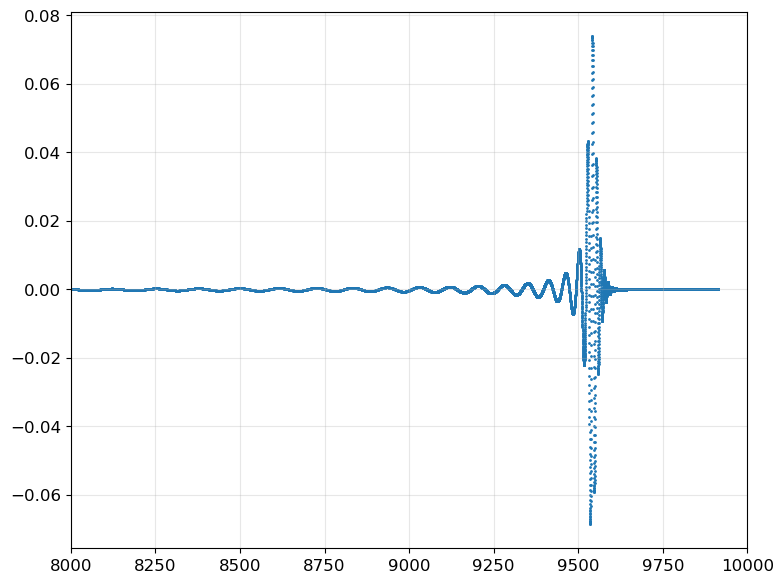

In [35]:
plt.scatter(dd1[:, 0], dd1[:, 1], s=1)
plt.xlim(8000, 10000)
plt.show()

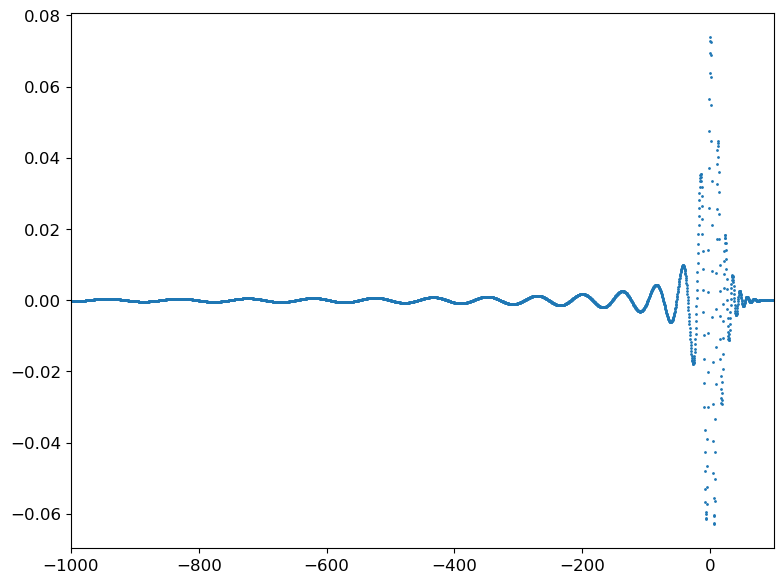

In [80]:
plt.scatter(wfsxs.time_axis, wfsxs.mode(2, 2), s=1)
plt.xlim(-1000, 100)
plt.grid()
plt.show()